# A2.5 L1 vs L2正则化:稀疏性与平滑性的数学解析与可视化

在本Notebook中，我将尝试探讨L1和L2正则化，分析为什么L1正则化倾向于得到稀疏解，而L2正则化倾向于得到平滑的解。下边将结合数学推导、直观解释和可视化来解释这个问题。

## 1. 正则化简介
在机器学习中，正则化是一种防止过拟合的技术。它通过在损失函数中添加一个惩罚项来实现。两种最常见的正则化方法是L1正则化和L2正则化。
一般形式的正则化损失函数可以表示为:
$$L_{regularized} = L_{original} + \lambda R(w)$$
其中 $L_{original}$ 是原始损失函数， $R(w)$ 是正则化项， $\lambda$ 是正则化强度。
- L1正则化: $R(w) = \sum_{i} |w_i|$
- L2正则化: $R(w) = \sum_{i} w_i^2$

## 2. 数学解释
### 2.1. 损失函数与正则化项
以线性回归为例，原始的损失函数（最小化均方误差）为：
$$
J(\mathbf{w}) = \frac{1}{2} \sum_{i=1}^N (y_i - \mathbf{w}^\top \mathbf{x}_i)^2
$$
加入正则化项后，损失函数变为：
$$
J_{\text{reg}}(\mathbf{w}) = J(\mathbf{w}) + \lambda R(\mathbf{w})
$$
其中：
- $\lambda$：正则化系数，控制正则化项的影响程度。
- $R(\mathbf{w})$：正则化项，常见的有L1和L2正则化。

### 2.2. L1正则化与稀疏解
L1正则化的正则化项为：
$$
R_{\text{L1}}(\mathbf{w}) = \|\mathbf{w}\|_1 = \sum_{j=1}^p |w_j|
$$
加入L1正则化后的损失函数为：
$$
J_{\text{L1}}(\mathbf{w}) = \frac{1}{2} \sum_{i=1}^N (y_i - \mathbf{w}^\top \mathbf{x}_i)^2 + \lambda \sum_{j=1}^p |w_j|
$$

由于L1正则化的绝对值函数在$w_j=0$处不可导，在一般的机器学习中，往往采用次梯度进行优化。L1正则化项的次梯度为：
$$
\frac{\partial R_{\text{L1}}}{\partial w_j} =
\begin{cases}
1, & w_j > 0 \\
-1, & w_j < 0 \\
\text{任意值} \in [-1, 1], & w_j = 0
\end{cases}
$$
在梯度下降中，权重更新规则为：
$$
w_j^{(t+1)} = w_j^{(t)} - \eta \left( \frac{\partial J}{\partial w_j^{(t)}} + \lambda \frac{\partial R_{\text{L1}}}{\partial w_j^{(t)}} \right)
$$

通过分析加入L1正则化后的权重更新规则，我认为L1正则化倾向于得到稀疏解的原因为：L1正则化的梯度在$w_j$的正负两侧有不同的符号，这会引导权重向零逼近，当$w_j$非常小时，$\lambda$的影响占主导，可能使得$w_j$更新为零。结果是许多权重被压缩为零，得到稀疏解。

## 2.3 L2正则化与平滑解

L2正则化的正则化项为：
$$
R_{\text{L2}}(\mathbf{w}) = \|\mathbf{w}\|_2^2 = \sum_{j=1}^p w_j^2
$$
加入L2正则化后的损失函数为：
$$
J_{\text{L2}}(\mathbf{w}) = \frac{1}{2} \sum_{i=1}^N (y_i - \mathbf{w}^\top \mathbf{x}_i)^2 + \lambda \sum_{j=1}^p w_j^2
$$

L2正则化项的梯度为：
$$
\frac{\partial R_{\text{L2}}}{\partial w_j} = 2w_j
$$
在梯度下降中，权重更新规则为：
$$
w_j^{(t+1)} = w_j^{(t)} - \eta \left( \frac{\partial J}{\partial w_j^{(t)}} + 2\lambda w_j^{(t)} \right)
$$
$$
w_j^{(t+1)} = w_j^{(t)} (1 - 2\eta \lambda) - \eta \frac{\partial J}{\partial w_j^{(t)}}
$$

通过分析加入L1正则化后的权重更新规则，我认为L1正则化倾向于得到稀疏解的原因为：L2正则化对大的权重有更强的惩罚，对小的权重影响较小，因此权重被均匀地缩减，但不会被压缩为零。结果是权重的大小被平滑地调节，得到平滑解。

## 3. 直观解释与可视化
为了更直观地理解L1和L2正则化的效果，下面可视化两者的具体行为。下边的代码生成了无正则化、L1正则化和L2正则化的损失函数landscape，分别展示了三维表面图和等高线图。

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

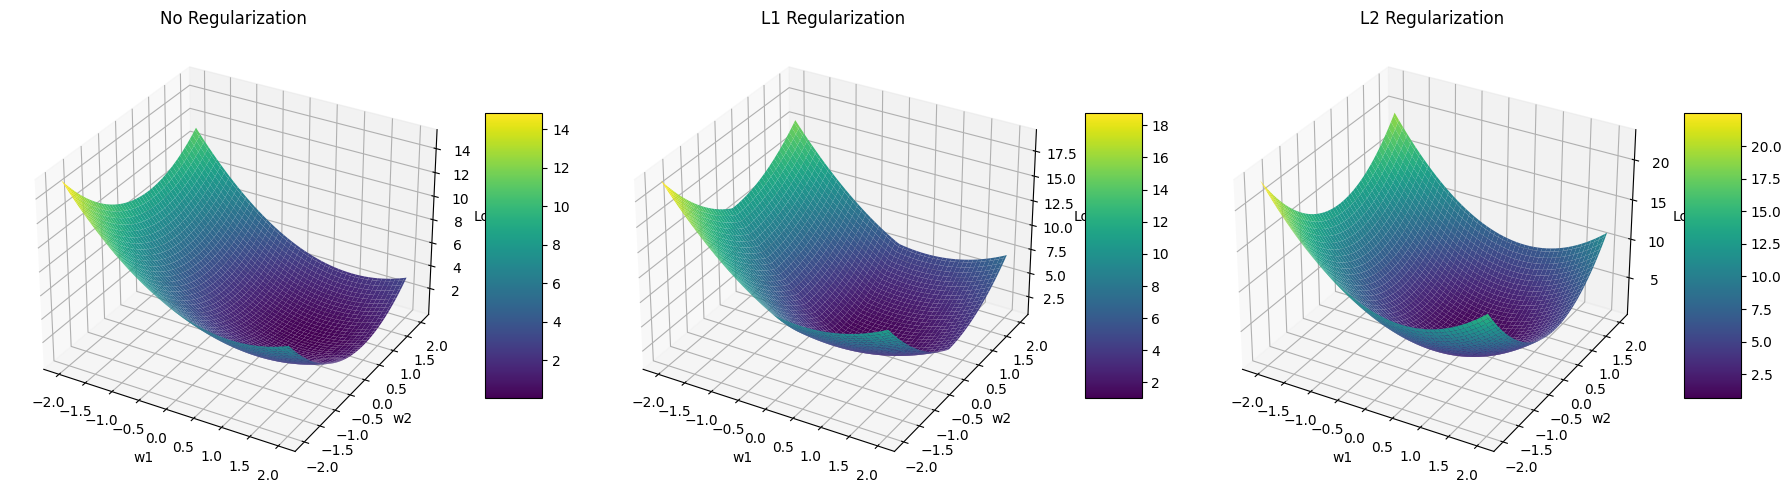

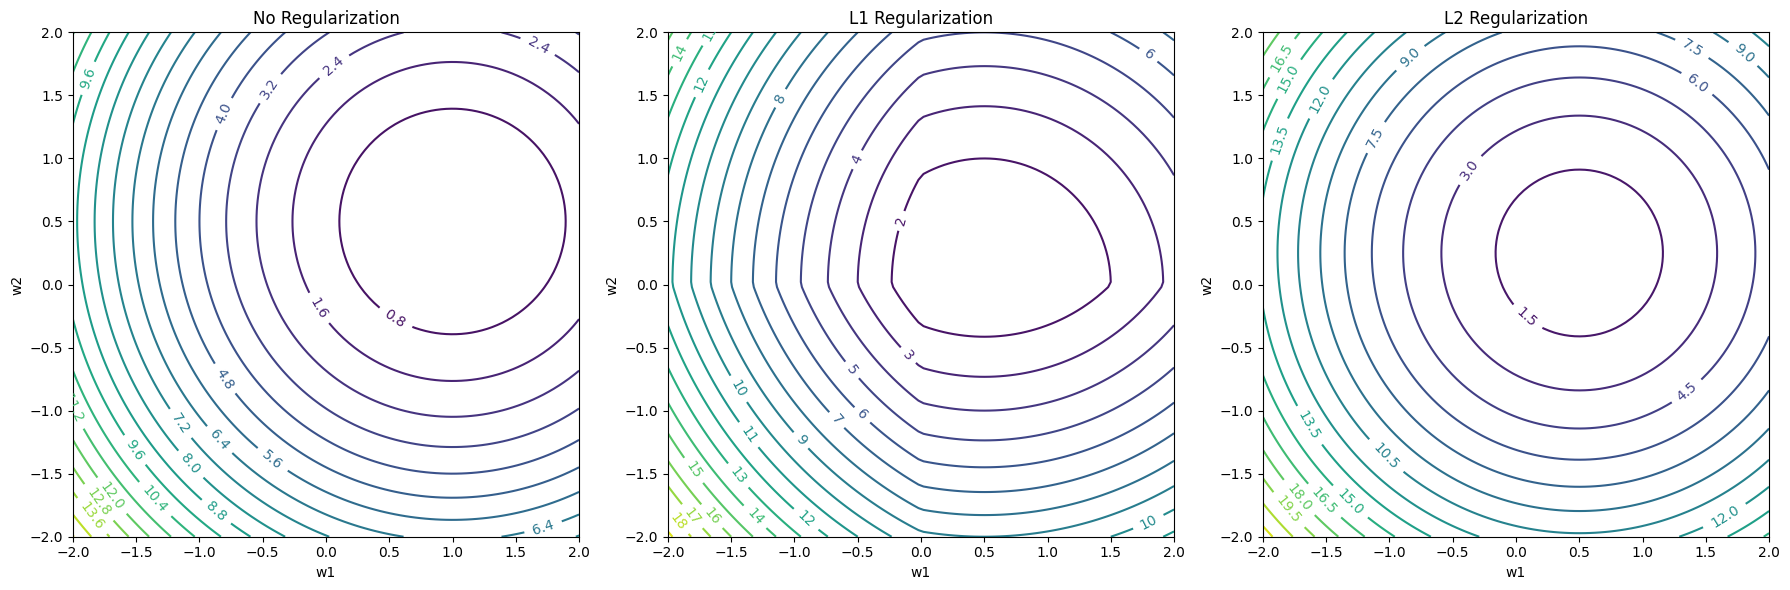

In [5]:
def loss_function(w1, w2, reg_type='none', lambda_=1):
    # 随便设置一个损失函数
    loss = (w1 - 1)**2 + (w2 - 0.5)**2
    if reg_type == 'l1':
        loss += lambda_ * (np.abs(w1) + np.abs(w2))
    elif reg_type == 'l2':
        loss += lambda_ * (w1**2 + w2**2)
    return loss

w1 = np.linspace(-2, 2, 100)
w2 = np.linspace(-2, 2, 100)
W1, W2 = np.meshgrid(w1, w2)

loss_none = loss_function(W1, W2, 'none')
loss_l1 = loss_function(W1, W2, 'l1')
loss_l2 = loss_function(W1, W2, 'l2')

fig = plt.figure(figsize=(18, 6))

def plot_loss(ax, W1, W2, loss, title):
    surf = ax.plot_surface(W1, W2, loss, cmap='viridis')
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_zlabel('Loss')
    ax.set_title(title)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

ax1 = fig.add_subplot(131, projection='3d')
plot_loss(ax1, W1, W2, loss_none, 'No Regularization')

ax2 = fig.add_subplot(132, projection='3d')
plot_loss(ax2, W1, W2, loss_l1, 'L1 Regularization')

ax3 = fig.add_subplot(133, projection='3d')
plot_loss(ax3, W1, W2, loss_l2, 'L2 Regularization')

plt.tight_layout()
plt.show()

# 绘制等高线图
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

def plot_contour(ax, W1, W2, loss, title):
    contour = ax.contour(W1, W2, loss, levels=20)
    ax.clabel(contour, inline=1, fontsize=10)
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title(title)

plot_contour(ax1, W1, W2, loss_none, 'No Regularization')
plot_contour(ax2, W1, W2, loss_l1, 'L1 Regularization')
plot_contour(ax3, W1, W2, loss_l2, 'L2 Regularization')

plt.tight_layout()
plt.show()

### 3.1 L1正则化可视化解读

在L1正则化的等高线图中，不难看到等高线在几个方向上有比较明显的棱角。这些棱角正是最优解更可能出现的地方，因为它们对应着某些权重为零的情况。

L1正则化项可以看作是在原始目标函数外加了一个"菱形"约束。这个菱形与原始目标函数的等高线相交的地方，更有可能在高纬空间的坐标轴上（即某个维度为0的情况），这就导致了稀疏解。

### 3.2 L2正则化可视化解读

相比之下，L2正则化的等高线是光滑的椭圆形。L2正则化项可以看作是在原始目标函数外加了一个"圆形"约束。这个圆形与原始目标函数的等高线相交的地方，通常不会在坐标轴上，而是在某个所有权重都非零的点上。

这就解释了为什么L2正则化倾向于得到所有特征都有小的非零权重的平滑解。